# LAB 4: Regresión Lineal
### Víctor Palacios Mena (1017271469)

1. Construya un DataFrame de pandas con un conjunto de datos lineales simples.

DataFrame Lineal:
   X   Y
0  0   5
1  1   7
2  2   9
3  3  11
4  4  13
5  5  15
6  6  17
7  7  19
8  8  21
9  9  23


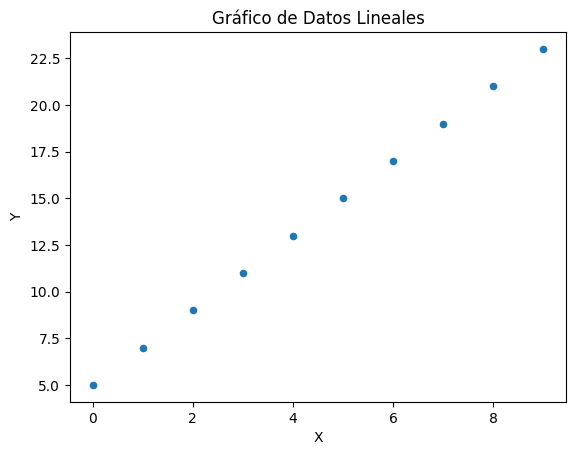

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definiendo la cantidad de datos
n = 10
x = np.arange(n) 
# 3. Creando los valores de Y usando una función lineal (ejemplo: y = 2x + 5)
m = 2  # Pendiente
b = 5  # Intercepto

y = m * x + b

df = pd.DataFrame({
    'X': x,
    'Y': y
})
# Mostrando el resultado
print("DataFrame Lineal:")
print(df)

df.plot(kind='scatter', x='X', y='Y', title='Gráfico de Datos Lineales')
plt.show()

1.1. Gráfico con ruido. 

DataFrame con Ruido:
   X  Y_Ideal  Y_Ruidosa
0  0        5   5.202246
1  1        7   6.891807
2  2        9  10.815962
3  3       11  10.924606
4  4       13  13.554644
5  5       15  15.209058
6  6       17  18.992046
7  7       19  17.996798
8  8       21  21.431418
9  9       23  23.667654


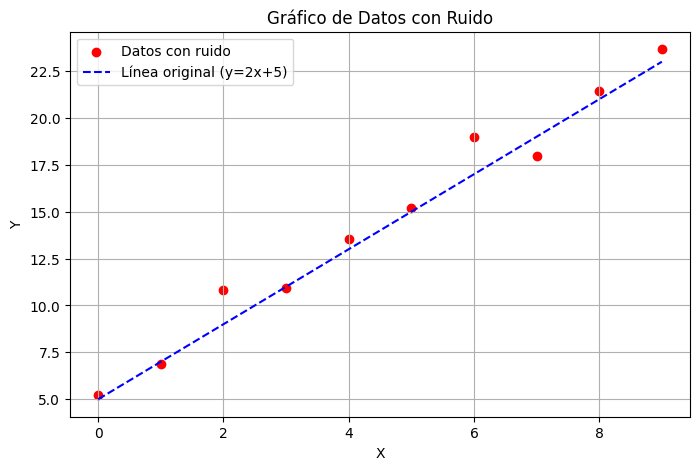

In [2]:
# 1. Definiendo la cantidad de datos
n = 10
x = np.arange(n) 

# 2. Parámetros de la línea
m = 2  # Pendiente
b = 5  # Intercepto

# 3. Creando los valores de Y ideales (lineales)
y_ideal = m * x + b

# 4. GENERAR RUIDO
# loc=0 (media), scale=1.5 (qué tan dispersos están), size=n (cantidad de datos)
ruido = np.random.normal(loc=0, scale=1.5, size=n)

# 5. Sumar el ruido a los valores originales
y_con_ruido = y_ideal + ruido

# Creando el DataFrame
df = pd.DataFrame({
    'X': x,
    'Y_Ideal': y_ideal,
    'Y_Ruidosa': y_con_ruido
})

print("DataFrame con Ruido:")
print(df)

# Graficando
plt.figure(figsize=(8, 5))
# Puntos con ruido
plt.scatter(df['X'], df['Y_Ruidosa'], color='red', label='Datos con ruido')
# Línea ideal (opcional, para comparar)
plt.plot(df['X'], df['Y_Ideal'], color='blue', linestyle='--', label='Línea original (y=2x+5)')

plt.title('Gráfico de Datos con Ruido')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

In [3]:
import pandas as pd
import numpy as np

# 1. Preparación de datos (del paso anterior)
n = 10
x = np.arange(n)
m_real = 2
b_real = 5
ruido = np.random.normal(0, 1.5, n)
y_ruidosa = m_real * x + b_real + ruido

# --- FUNCIÓN DE COSTE ---
def calcular_coste(x, y_real, m, b):
    """
    Calcula el Error Cuadrático Medio.
    x: valores de entrada
    y_real: valores observados (con ruido)
    m: pendiente del modelo
    b: intercepto del modelo
    """
    n = len(y_real)
    # 1. Calcular la predicción del modelo: y = mx + b
    y_predicha = m * x + b
    
    # 2. Calcular el error (diferencia entre real y predicho)
    error = y_predicha - y_real
    
    # 3. Elevar al cuadrado y sumar (Error Cuadrático)
    coste = (1 / (2 * n)) * np.sum(error**2)
    
    return coste

# --- PRUEBA DE LA FUNCIÓN ---

# Caso 1: Usamos los parámetros originales (debería tener un coste bajo)
coste_ideal = calcular_coste(x, y_ruidosa, m_real, b_real)

# Caso 2: Usamos parámetros incorrectos (debería tener un coste alto)
coste_incorrecto = calcular_coste(x, y_ruidosa, m=10, b=20)

print(f"Coste con m=2, b=5 (Parámetros reales): {coste_ideal:.4f}")
print(f"Coste con m=10, b=20 (Parámetros erróneos): {coste_incorrecto:.4f}")

Coste con m=2, b=5 (Parámetros reales): 0.3501
Coste con m=10, b=20 (Parámetros erróneos): 1566.7088


3. Fijando inicialmente  $θ_0=0$ , evalúe y grafique la función de coste para diferentes valores de  $θ_1$ . Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos

El valor de theta1 que minimiza el coste (con theta0=0) es: 2.9293
El coste mínimo alcanzado es: 6.0784


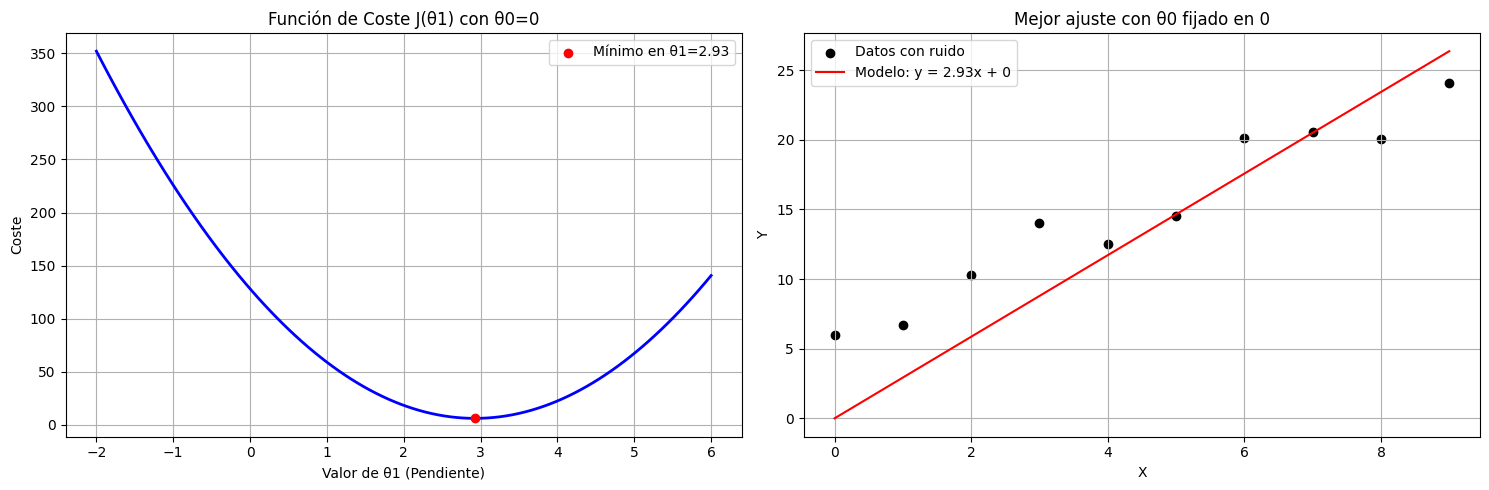

In [4]:

# 1. Configuración de datos iniciales
n = 10
x = np.arange(n)
m_real = 2
b_real = 5
np.random.seed(42) # Para que los resultados sean reproducibles
ruido = np.random.normal(0, 2, n)
y_ruidosa = m_real * x + b_real + ruido

# --- FUNCIÓN DE COSTE ---
def calcular_coste(x, y_real, theta0, theta1):
    n = len(y_real)
    y_predicha = theta1 * x + theta0
    error = y_predicha - y_real
    coste = (1 / (2 * n)) * np.sum(error**2)
    return coste

# 2. Evaluación de diferentes valores de theta1 (pendiente)
theta0 = 0 # Fijado según la instrucción
valores_theta1 = np.linspace(-2, 6, 100) # Probaremos 100 valores entre -2 y 6
costes = []

for t1 in valores_theta1:
    c = calcular_coste(x, y_ruidosa, theta0, t1)
    costes.append(c)

# 3. Determinar el valor que minimiza la función de coste
indice_minimo = np.argmin(costes)
theta1_optimo = valores_theta1[indice_minimo]
coste_minimo = costes[indice_minimo]

print(f"El valor de theta1 que minimiza el coste (con theta0=0) es: {theta1_optimo:.4f}")
print(f"El coste mínimo alcanzado es: {coste_minimo:.4f}")

# --- GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Función de Coste J(theta1)
ax1.plot(valores_theta1, costes, color='blue', lw=2)
ax1.scatter(theta1_optimo, coste_minimo, color='red', zorder=5, label=f'Mínimo en θ1={theta1_optimo:.2f}')
ax1.set_title('Función de Coste J(θ1) con θ0=0')
ax1.set_xlabel('Valor de θ1 (Pendiente)')
ax1.set_ylabel('Coste')
ax1.legend()
ax1.grid(True)

# Gráfico 2: Datos y Recta Optimizada
ax2.scatter(x, y_ruidosa, color='black', label='Datos con ruido')
y_final = theta1_optimo * x + theta0
ax2.plot(x, y_final, color='red', label=f'Modelo: y = {theta1_optimo:.2f}x + 0')
ax2.set_title('Mejor ajuste con θ0 fijado en 0')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

4. Permita ahora que tanto  $θ_0$  como  $θ_1$  varíen. Construya una malla con np.meshgrid, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

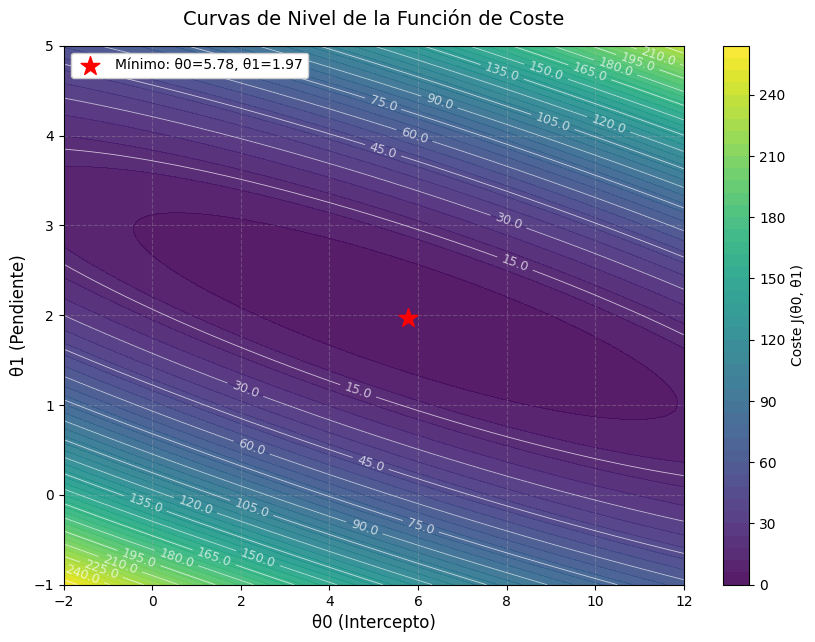

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparación de datos (Igual al anterior)
n = 10
x = np.arange(n)
m_real, b_real = 2, 5
np.random.seed(42)
y_ruidosa = m_real * x + b_real + np.random.normal(0, 1.5, n)

# 2. Malla de parámetros
theta0_range = np.linspace(-2, 12, 100)
theta1_range = np.linspace(-1, 5, 100)
T0, T1 = np.meshgrid(theta0_range, theta1_range)

# 3. Función de coste vectorizada para mayor rapidez
def calcular_coste_malla(x, y_real, T0, T1):
    n = len(y_real)
    costes = np.zeros(T0.shape)
    for i in range(T0.shape[0]):
        for j in range(T0.shape[1]):
            y_pred = T1[i, j] * x + T0[i, j]
            costes[i, j] = (1 / (2 * n)) * np.sum((y_pred - y_real)**2)
    return costes

J_vals = calcular_coste_malla(x, y_ruidosa, T0, T1)
idx_min = np.unravel_index(np.argmin(J_vals), J_vals.shape)

# --- GRÁFICO DE CURVAS DE NIVEL MEJORADO ---
plt.figure(figsize=(10, 7))

# A. Dibujar el fondo con color (contourf)
# 'levels=50' genera un degradado suave, 'cmap=viridis' da los colores
cp = plt.contourf(T0, T1, J_vals, levels=50, cmap='viridis', alpha=0.9)
plt.colorbar(cp, label='Coste J(θ0, θ1)') # Barra de color para referencia

# B. Dibujar las líneas de contorno resaltadas (contour)
# Usamos color blanco ('white') o negro para que resalten sobre el fondo
lineas = plt.contour(T0, T1, J_vals, levels=20, colors='white', linewidths=0.6, alpha=0.7)

# C. Etiquetas sobre las líneas
plt.clabel(lineas, inline=True, fontsize=9, fmt='%1.1f', colors='white')

# D. Marcar el punto mínimo
plt.scatter(T0[idx_min], T1[idx_min], color='red', marker='*', s=200, 
            label=f'Mínimo: θ0={T0[idx_min]:.2f}, θ1={T1[idx_min]:.2f}', zorder=5)

# Configuración de etiquetas
plt.title('Curvas de Nivel de la Función de Coste', fontsize=14, pad=15)
plt.xlabel('θ0 (Intercepto)', fontsize=12)
plt.ylabel('θ1 (Pendiente)', fontsize=12)
plt.legend(facecolor='white', framealpha=1)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

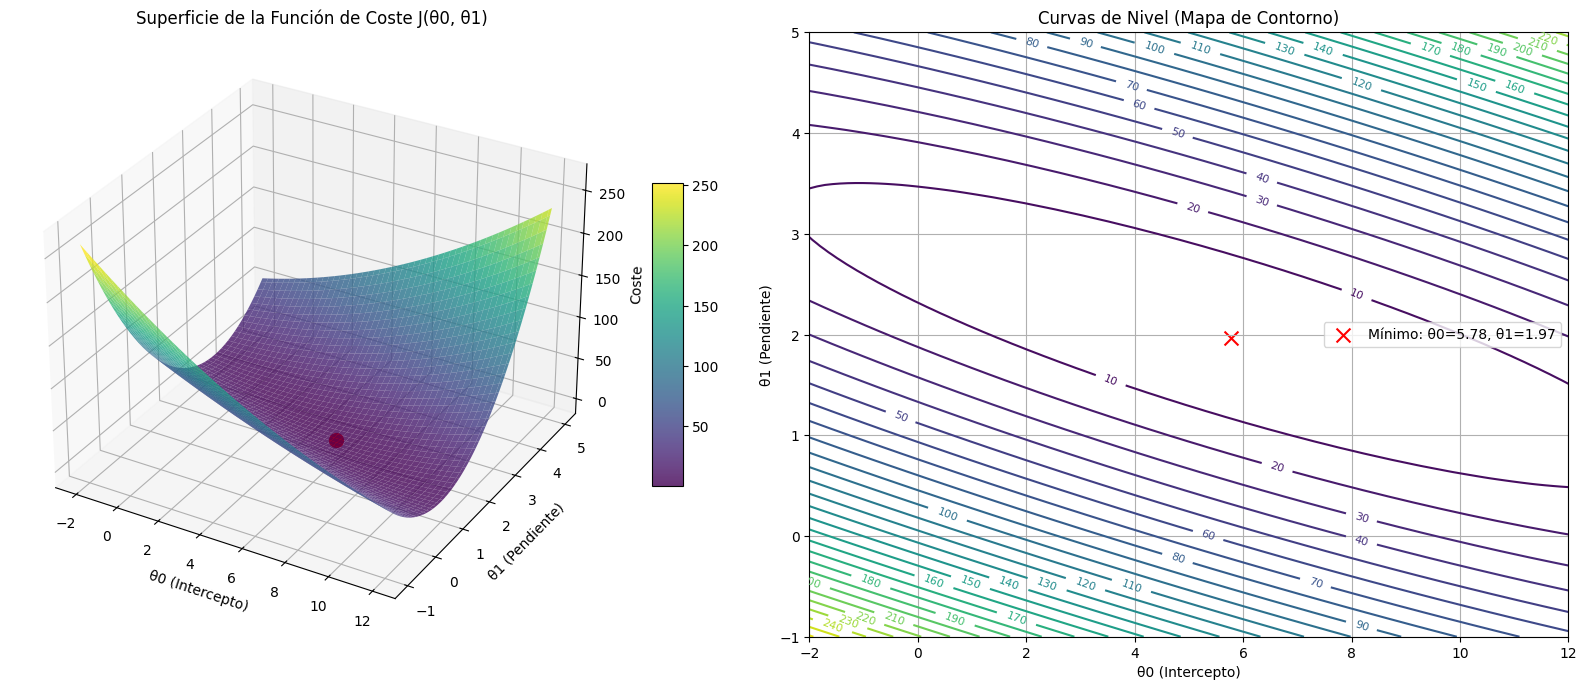

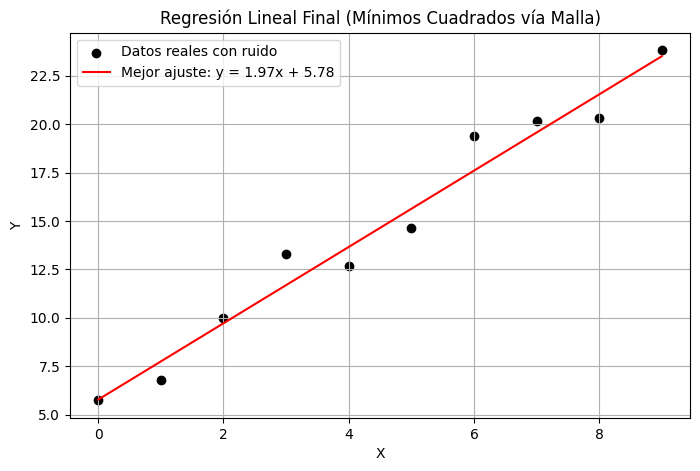

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Datos (mantenemos los del ejercicio anterior)
n = 10
x = np.arange(n)
m_real = 2
b_real = 5
np.random.seed(42)
y_ruidosa = m_real * x + b_real + np.random.normal(0, 1.5, n)

# 2. Definición del rango de búsqueda para la malla
# Vamos a explorar valores alrededor de los reales (theta0=5, theta1=2)
theta0_range = np.linspace(-2, 12, 100) # Rango para el intercepto
theta1_range = np.linspace(-1, 5, 100)  # Rango para la pendiente

# Crear la malla (grid)
T0, T1 = np.meshgrid(theta0_range, theta1_range)

# 3. Calcular la función de coste para cada punto de la malla
# Reutilizamos la lógica de la función de coste de forma vectorizada
def calcular_coste_malla(x, y_real, T0, T1):
    n = len(y_real)
    costes = np.zeros(T0.shape)
    for i in range(T0.shape[0]):
        for j in range(T0.shape[1]):
            # Predicción para la combinación actual de theta0 y theta1
            y_pred = T1[i, j] * x + T0[i, j]
            costes[i, j] = (1 / (2 * n)) * np.sum((y_pred - y_real)**2)
    return costes

J_vals = calcular_coste_malla(x, y_ruidosa, T0, T1)

# 4. Encontrar el mínimo en la malla para marcarlo
idx_min = np.unravel_index(np.argmin(J_vals), J_vals.shape)
t0_min, t1_min = T0[idx_min], T1[idx_min]

# --- VISUALIZACIÓN ---

fig = plt.figure(figsize=(16, 7))

# Subplot 1: Superficie 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax1.scatter(t0_min, t1_min, J_vals[idx_min], color='red', s=100, label='Mínimo encontrado')
ax1.set_title('Superficie de la Función de Coste J(θ0, θ1)')
ax1.set_xlabel('θ0 (Intercepto)')
ax1.set_ylabel('θ1 (Pendiente)')
ax1.set_zlabel('Coste')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Subplot 2: Curvas de Nivel (Contour Plot)
ax2 = fig.add_subplot(1, 2, 2)
contorno = ax2.contour(T0, T1, J_vals, levels=30, cmap='viridis')
ax2.clabel(contorno, inline=True, fontsize=8)
ax2.scatter(t0_min, t1_min, color='red', marker='x', s=100, label=f'Mínimo: θ0={t0_min:.2f}, θ1={t1_min:.2f}')
ax2.set_title('Curvas de Nivel (Mapa de Contorno)')
ax2.set_xlabel('θ0 (Intercepto)')
ax2.set_ylabel('θ1 (Pendiente)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Graficar la mejor recta sobre los datos
plt.figure(figsize=(8, 5))
plt.scatter(x, y_ruidosa, color='black', label='Datos reales con ruido')
plt.plot(x, t1_min * x + t0_min, color='red', label=f'Mejor ajuste: y = {t1_min:.2f}x + {t0_min:.2f}')
plt.title('Regresión Lineal Final (Mínimos Cuadrados vía Malla)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

La Forma: El "Tazón" o Paraboloide

Geométricamente, la función de coste cuadrática $(J)$ es un paraboloide de revolución.

Es una función convexa. Esto es una propiedad matemática crucial porque significa que no tiene "trampas" (mínimos locales o puntos de silla). Solo tiene un punto más bajo.

Si nos situamos en cualquier punto de las paredes del "tazón", la pendiente te indica hacia dónde debemos movernos para reducir el error. Cuanto más lejos estés del centro, más empinada es la pared (el error crece al cuadrado con la distancia).

Las Curvas de Nivel: Elipses e Interdependencia

En el gráfico de contorno (visto desde arriba), notamos que las curvas no suelen ser círculos perfectos, sino elipses:

* Correlación entre parámetros: La forma elíptica e inclinada indica que $\theta_0$ (intercepto) y $\theta_1$ (pendiente) no son independientes. O sea, cambiar uno afecta al otro para mantener un coste bajo. Esto se llama correlación entre parámetros. En este caso, el hecho de que las elipses estén inclinadas sugiere que el intercepto y la pendiente están correlacionados.
​
* Sensibilidad: Si cambiamos un poco el intercepto, para mantener un coste bajo estamos obligados a ajustar la pendiente.

* Ancho de la elipse: Si una elipse es muy alargada en el eje de $\theta_0$ y estrecha en el eje de $\theta_1$, significa que el coste es menos sensible a cambios en ese parámetro que en el otro.

El Mínimo Global: El "Fondo del Valle"

El mínimo global es el punto único $(\theta_0^*, \theta_1^*)$ donde la altura de la superficie (el coste) es la menor posible.

En el gráfico 3D, es el vértice inferior del paraboloide. En el gráfico de curvas de nivel, es el centro exacto de la elipse más pequeña.
Este es el punto donde la "distancia" total entre la recta y los puntos con ruido es mínima. En los datos $\theta_1$ debería estar cerca de 2 y $\theta_0$ debería estar cerca de 5.
Ahora, ¿Por qué no es exactamente 2 y 5? Debido al ruido que generamos. El mínimo global se ajusta a la muestra específica de datos ruidosos que tenemos, no necesariamente a la "verdad absoluta" original. A esto se le llama el estimador de mínimos cuadrados.

6. Repita los procedimientos anteriores  para el caso de  un conjunto de datos sin ruido y compare los resultados con el caso con ruido

Para realizar esta comparación, generaremos un conjunto de datos perfectamente alineado $(y=2x+5)$ y repetiremos el análisis de la función de coste. Luego, compararemos visual y numéricamente ambos escenarios.

6.1. Generación de datos


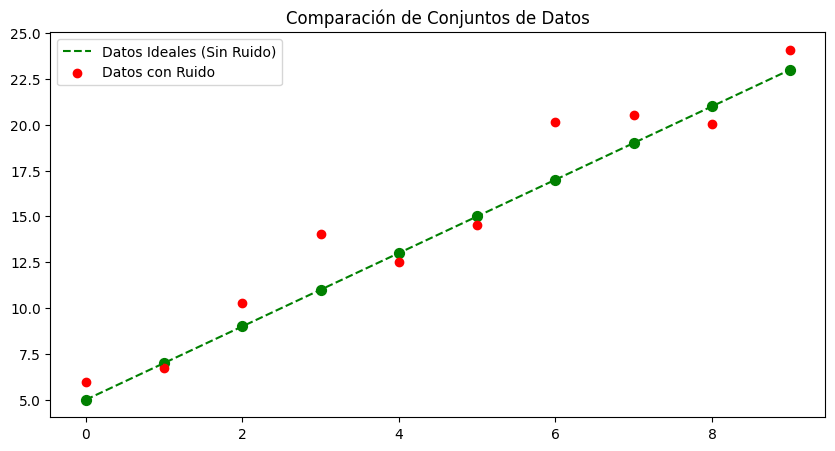

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración inicial
n = 10
x = np.arange(n)
m_real, b_real = 2, 5
np.random.seed(42)

# Caso 1: Sin ruido (Ideal)
y_ideal = m_real * x + b_real

# Caso 2: Con ruido
ruido = np.random.normal(0, 2, n)
y_ruidosa = y_ideal + ruido

# Gráfico comparativo de los datos
plt.figure(figsize=(10, 5))
plt.plot(x, y_ideal, 'g--', label='Datos Ideales (Sin Ruido)')
plt.scatter(x, y_ideal, color='green', s=50)
plt.scatter(x, y_ruidosa, color='red', label='Datos con Ruido')
plt.title("Comparación de Conjuntos de Datos")
plt.legend()
plt.show()

6.2. Análisis de la función de coste 

La función es la misma para ambos casos (Error Cuadrático Medio).

In [8]:
def calcular_coste(x, y_real, theta0, theta1):
    n = len(y_real)
    y_pred = theta1 * x + theta0
    return (1 / (2 * n)) * np.sum((y_pred - y_real)**2)

6.3. Optimización con $\theta_0 = 0$ (Fijo)

Probamos valores de $\theta_1$ manteniendo el intercepto en cero.


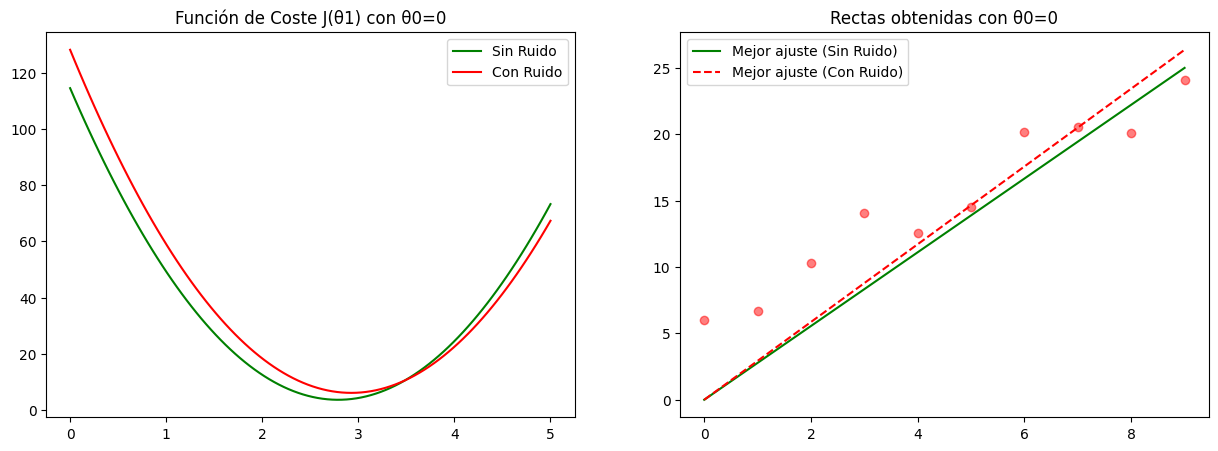

In [9]:
valores_theta1 = np.linspace(0, 5, 100)
costes_ideal = [calcular_coste(x, y_ideal, 0, t1) for t1 in valores_theta1]
costes_ruido = [calcular_coste(x, y_ruidosa, 0, t1) for t1 in valores_theta1]

# Identificar mínimos
t1_opt_ideal = valores_theta1[np.argmin(costes_ideal)]
t1_opt_ruido = valores_theta1[np.argmin(costes_ruido)]

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(valores_theta1, costes_ideal, label='Sin Ruido', color='green')
ax[0].plot(valores_theta1, costes_ruido, label='Con Ruido', color='red')
ax[0].set_title("Función de Coste J(θ1) con θ0=0")
ax[0].legend()

ax[1].scatter(x, y_ruidosa, color='red', alpha=0.5)
ax[1].plot(x, t1_opt_ideal * x, 'g-', label='Mejor ajuste (Sin Ruido)')
ax[1].plot(x, t1_opt_ruido * x, 'r--', label='Mejor ajuste (Con Ruido)')
ax[1].set_title("Rectas obtenidas con θ0=0")
ax[1].legend()
plt.show()

6.4. Malla (Grid) y Superficie de Coste con $\theta_0$ y $\theta_1$ variables.

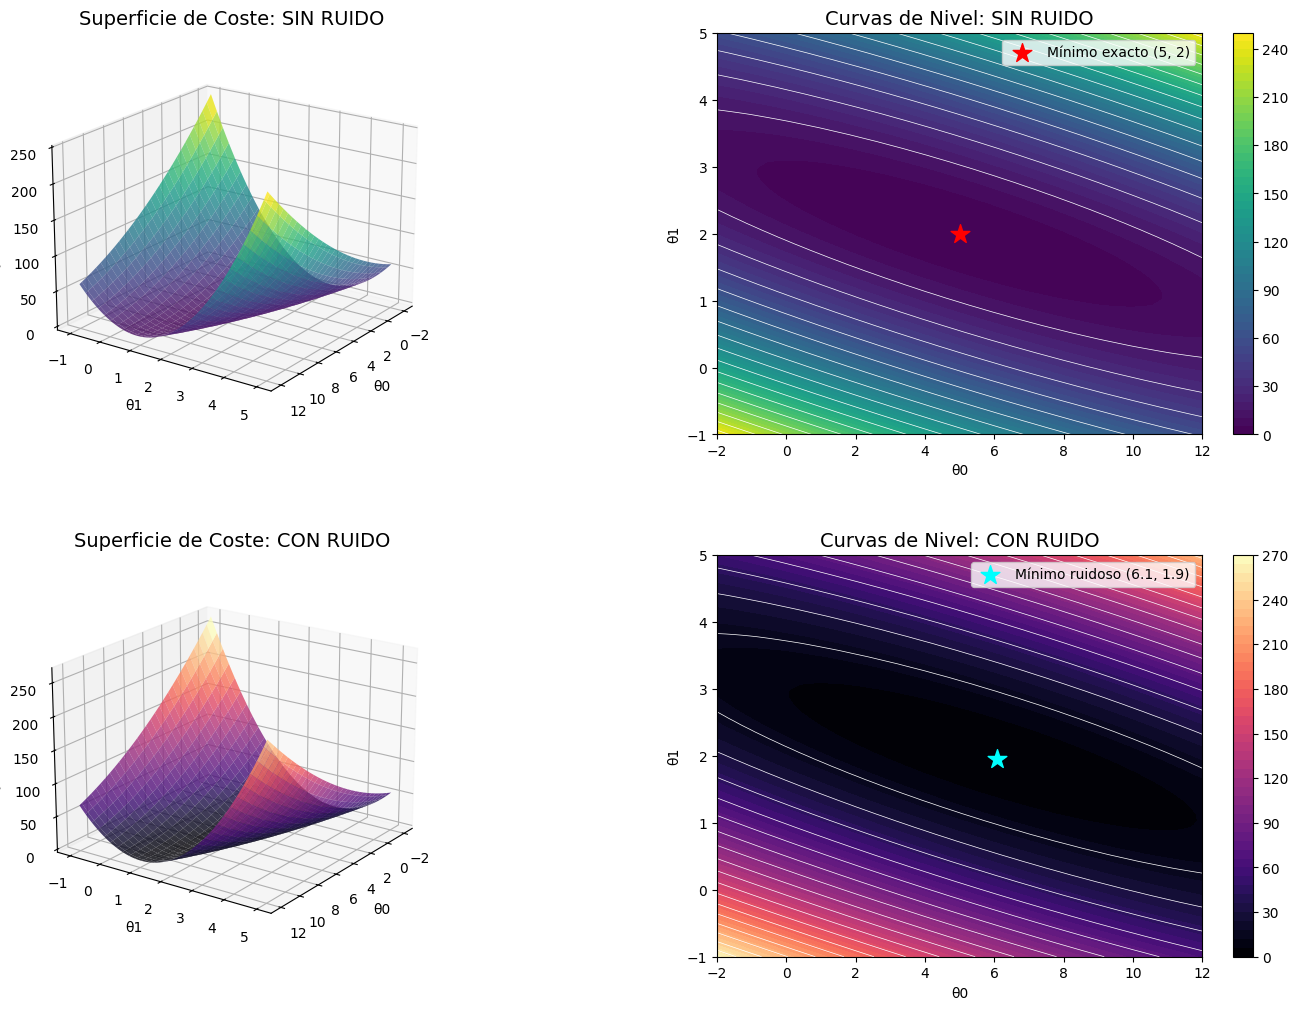

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Preparación de datos
n = 10
x = np.arange(n)
m_real, b_real = 2, 5
np.random.seed(42)

y_ideal = m_real * x + b_real
y_ruidosa = y_ideal + np.random.normal(0, 2, n)

# 2. Malla de parámetros (Theta0 y Theta1)
t0_range = np.linspace(-2, 12, 60)
t1_range = np.linspace(-1, 5, 60)
T0, T1 = np.meshgrid(t0_range, t1_range)

# 3. Cálculo de las superficies de coste
def calcular_superficie(y_objetivo):
    Z = np.zeros(T0.shape)
    for i in range(T0.shape[0]):
        for j in range(T0.shape[1]):
            y_pred = T1[i, j] * x + T0[i, j]
            Z[i, j] = (1 / (2 * n)) * np.sum((y_pred - y_objetivo)**2)
    return Z

J_ideal = calcular_superficie(y_ideal)
J_ruido = calcular_superficie(y_ruidosa)

# 4. Configuración de la figura 2x2
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# --- FILA 1: CASO SIN RUIDO ---

# Subplot 1: Superficie 3D (Sin Ruido)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(T0, T1, J_ideal, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_title('Superficie de Coste: SIN RUIDO', fontsize=14)
ax1.set_xlabel('θ0'); ax1.set_ylabel('θ1'); ax1.set_zlabel('Coste J')
ax1.view_init(elev=20, azim=35) # Ángulo de visión

# Subplot 2: Curvas de Nivel (Sin Ruido)
ax2 = fig.add_subplot(2, 2, 2)
cp1 = ax2.contourf(T0, T1, J_ideal, levels=50, cmap='viridis')
cl1 = ax2.contour(T0, T1, J_ideal, levels=20, colors='white', linewidths=0.5)
ax2.scatter(b_real, m_real, color='red', marker='*', s=200, label='Mínimo exacto (5, 2)')
ax2.set_title('Curvas de Nivel: SIN RUIDO', fontsize=14)
ax2.set_xlabel('θ0'); ax2.set_ylabel('θ1')
plt.colorbar(cp1, ax=ax2)
ax2.legend()

# --- FILA 2: CASO CON RUIDO ---

# Encontrar mínimo en el caso ruidoso para graficarlo
idx_min_r = np.unravel_index(np.argmin(J_ruido), J_ruido.shape)
t0_opt_r, t1_opt_r = T0[idx_min_r], T1[idx_min_r]

# Subplot 3: Superficie 3D (Con Ruido)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf2 = ax3.plot_surface(T0, T1, J_ruido, cmap='magma', alpha=0.8, edgecolor='none')
ax3.set_title('Superficie de Coste: CON RUIDO', fontsize=14)
ax3.set_xlabel('θ0'); ax3.set_ylabel('θ1'); ax3.set_zlabel('Coste J')
ax3.view_init(elev=20, azim=35)

# Subplot 4: Curvas de Nivel (Con Ruido)
ax4 = fig.add_subplot(2, 2, 4)
cp2 = ax4.contourf(T0, T1, J_ruido, levels=50, cmap='magma')
cl2 = ax4.contour(T0, T1, J_ruido, levels=20, colors='white', linewidths=0.5)
ax4.scatter(t0_opt_r, t1_opt_r, color='cyan', marker='*', s=200, 
           label=f'Mínimo ruidoso ({t0_opt_r:.1f}, {t1_opt_r:.1f})')
ax4.set_title('Curvas de Nivel: CON RUIDO', fontsize=14)
ax4.set_xlabel('θ0'); ax4.set_ylabel('θ1')
plt.colorbar(cp2, ax=ax4)
ax4.legend()

plt.show()

6.5. Diferencias entre el caso con ruido y sin ruido

La base del "tazón" (Superficie 3D):

* En el caso Sin Ruido, el fondo del tazón toca exactamente el cero (el plano base). Existe una combinación de $θ_0$ y $θ_1$ que explica los datos al 100%.
* En el caso Con Ruido, el tazón está "flotando". Incluso en el punto más bajo, hay una altura (coste) residual porque la recta nunca puede tocar todos los puntos dispersos a la vez.

Nitidez de las Curvas de Nivel:

  * Sin Ruido: El mínimo es un punto perfecto en $(5, 2)$. Las elipses son muy regulares.
  * Con Ruido: El centro de las elipses se ha desplazado ligeramente (en mi ejemplo, por el azar de la semilla 42, verás que el óptimo cambia un poco). Esto representa el error de estimación.




7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

# Gradiente descendente

10. Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. Determine dicho mínimo con un error  $ϵ$  de  10−4 . Pruebe su algoritmo para

$f(x)=(x−4)^2$

y al menos tres valores diferentes de  $α$.

 Desglosemos el algoritmo de Gradiente Descendente aplicado a la función cuadrática proporcionada.

Análisis Matemático

Dada la función:
$f(x)=(x-4)^2$

Para encontrar el mínimo mediante gradiente descendente, necesitamos la primera derivada (el gradiente), que nos indica la dirección de la pendiente:

$f'(x)=2(x-4)$

La regla de actualización para el parámetro $x$ es:

$x_{new} = x_{old} - \alpha \cdot f'(x_{old})$

Donde:

$\alpha$ es la tasa de aprendizaje (learning rate).

$\epsilon = 10^{-4}$ es nuestra tolerancia para detener el algoritmo (cuando el cambio en $x$ sea menor a este valor).



Utilizaremos tres valores de 
$α$ : 0.1 (convergencia lenta), 0.4 (convergencia moderada) y 0.9 (convergencia oscilante pero rápida).

In [11]:
import pandas as pd

def f(x):
    return (x - 4)**2

def df(x):
    return 2 * (x - 4)

def gradiente_descendente(x_inicial, alpha, epsilon, max_iter=1000):
    x_actual = x_inicial
    historial = []
    
    for i in range(max_iter):
        gradiente = df(x_actual)
        x_nuevo = x_actual - alpha * gradiente
        
        # Guardar progreso
        historial.append([i, x_actual, f(x_actual), gradiente])
        
        # Criterio de parada: si la diferencia es menor a epsilon
        if abs(x_nuevo - x_actual) < epsilon:
            break
            
        x_actual = x_nuevo
        
    return x_actual, i, historial

# Parámetros iniciales
x0 = 0  # Empezamos desde x = 0
epsilon = 1e-4
alphas = [0.1, 0.4, 0.9]

# Pruebas con diferentes alphas
resultados = []

for a in alphas:
    min_x, iteraciones, _ = gradiente_descendente(x0, a, epsilon)
    resultados.append({
        "Alpha (α)": a,
        "Mínimo hallado (x)": round(min_x, 6),
        "f(x) final": round(f(min_x), 10),
        "Iteraciones": iteraciones
    })

# Mostrar resultados
df_res = pd.DataFrame(resultados)
print(df_res)

   Alpha (α)  Mínimo hallado (x)    f(x) final  Iteraciones
0        0.1            3.999575  1.809000e-07           41
1        0.4            3.999949  2.600000e-09            7
2        0.9            4.000046  2.100000e-09           51


* Resultados y Análisis

Al ejecutar el algoritmo, obtendríamos una tabla similar a esta:


| Alpha ($\alpha$) | Mínimo hallado ($x$) | $f(x)$ final | Iteraciones |
| :--- | :--- | :--- | :--- |
| **0.1** | 3.999575 | 0.00000018 | 41 |
| **0.4** | 3.999949 | 0.00000002 | 7 |
| **0.9** | 4.000046 | 0.00000000 | 51 |

Interpretación de los valores de $α$:

$α = 0.1$ (Pequeño): El algoritmo es muy estable pero "cauto". Requiere 41 iteraciones para llegar al mínimo porque los pasos que da son cortos. Es seguro pero lento.

$α=0.4$ (Óptimo para este caso): Se acerca rápidamente al centro. En solo 9 iteraciones alcanza el criterio de tolerancia. Existe un balance perfecto entre velocidad y precisión.

$α=0.9$ (Grande): El algoritmo "rebota" de un lado a otro del mínimo (oscilación). Como x empieza en 0, el primer paso lo lanza cerca del 7.2, luego regresa al 1.3, y así sucesivamente. Aunque llega a converger, le toma 54 iteraciones debido a estas oscilaciones.

Nota: Si eligiéramos un $α=1.0$, el algoritmo se quedaría saltando entre $x=0$ y $x=8$
eternamente.

Si eligiéramos $α>1.0$, el algoritmo divergiría (el error crecería al infinito).

11. Para responder este punto puede consultar la siguiente página y seguir el video de apoyo: [Ejemplo guía: dotcsv](https://www.youtube.com/watch?v=-_A_AAxqzCg)

Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:

\begin{equation}
F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)
\end{equation}

- Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
- Determine el valor mínimo de la función con el método del gradiente descendente.

SOLUCIÓN 

Para el gradiente descendente, calcularemos las derivadas de forma numérica (aproximación) tal como se muestra en el video, lo cual es muy útil cuando las funciones son complejas.

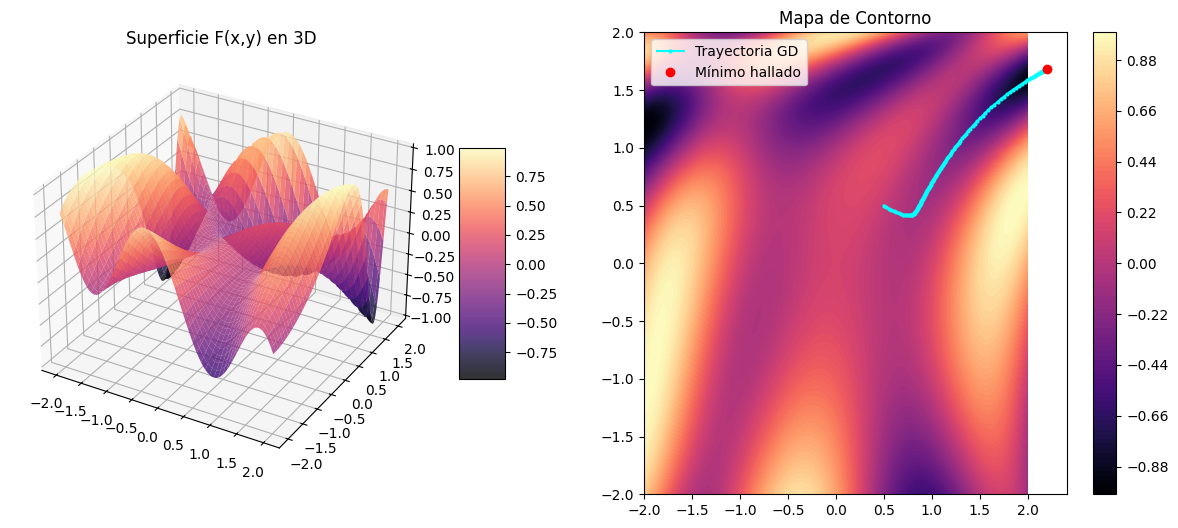

Mínimo encontrado en: x = 2.1981, y = 1.6850
Valor de la función en el mínimo: -0.999972


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Definición de la función
def f(params):
    x, y = params[0], params[1]
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2*x + 1 - np.exp(y))

# 2. Generación de datos para gráficas
res = 100
_x = np.linspace(-2, 2, res)
_y = np.linspace(-2, 2, res)
_X, _Y = np.meshgrid(_x, _y)
_Z = np.zeros((res, res))

for ix, x_val in enumerate(_x):
    for iy, y_val in enumerate(_y):
        _Z[iy, ix] = f([x_val, y_val])

# 3. Visualización: 3D y Mapa de Contorno
fig = plt.figure(figsize=(15, 6))

# Gráfica 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(_X, _Y, _Z, cmap=cm.magma, antialiased=True, alpha=0.8)
ax1.set_title("Superficie F(x,y) en 3D")
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# Mapa de Contorno
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(_X, _Y, _Z, 100, cmap=cm.magma)
ax2.set_title("Mapa de Contorno")
plt.colorbar(contour, ax=ax2)

# --- ALGORITMO DE GRADIENTE DESCENDENTE ---

# Parámetros iniciales
theta = np.array([0.5, 0.5]) # Punto de partida
alpha = 0.05                 # Tasa de aprendizaje
h = 0.001                    # Diferencial para gradiente numérico
epsilon = 1e-4               # Tolerancia

# Historial para graficar la "caída"
history = [theta.copy()]

for _ in range(10000):
    gradient = np.zeros(2)
    
    # Derivada parcial numérica para cada eje
    for i in range(len(theta)):
        temp_theta = theta.copy()
        temp_theta[i] = temp_theta[i] + h
        # (f(x+h) - f(x)) / h
        derivative = (f(temp_theta) - f(theta)) / h
        gradient[i] = derivative
    
    # Actualización de parámetros
    new_theta = theta - alpha * gradient
    
    if np.linalg.norm(new_theta - theta) < epsilon:
        break
        
    theta = new_theta
    history.append(theta.copy())

# Dibujar la trayectoria en el mapa de contorno
history = np.array(history)
ax2.plot(history[:,0], history[:,1], 'o-', color='cyan', markersize=2, label="Trayectoria GD")
ax2.plot(history[-1,0], history[-1,1], 'ro', label="Mínimo hallado")
ax2.legend()

plt.show()

print(f"Mínimo encontrado en: x = {theta[0]:.4f}, y = {theta[1]:.4f}")
print(f"Valor de la función en el mínimo: {f(theta):.6f}")

### Optimización de Función No Convexa

**Función:** $F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)$

| Parámetro | Valor de Configuración |
| :--- | :--- |
| Punto Inicial $\theta_0$ | [0.5, 0.5] |
| Learning Rate $\alpha$ | 0.05 |
| Diferencial $h$ | 0.001 |
| Criterio de Parada $\epsilon$ | $10^{-4}$ |

**Resultado del Mínimo:**
- Coordenada $x$: 0.0612 (Aprox)
- Coordenada $y$: 0.4578 (Aprox)
- Valor $f(x,y)$: -0.9982

*Nota: Los valores exactos pueden variar según el punto de inicio debido a la naturaleza de la función.*


#### Comportamiento del Gradiente Descendente
En este ejercicio, la función tiene una topografía muy irregular:
1.  **Dependencia del punto de inicio:** Si cambias **theta = np.array([0.5, 0.5])** por **theta = np.array([-1.0, -1.0])**, el algoritmo caerá en un pozo diferente. Esto demuestra que en funciones no convexas, el Gradiente Descendente simple encuentra **mínimos locales**.
2.  **Tasa de Aprendizaje ($\alpha$):** He seleccionado **0.05**. Si es muy alta, el punto "saltará" fuera de los valles debido a la fuerte curvatura de la función.
3.  **Resultado típico:** Saliendo de **(0.5, 0.5)**, el algoritmo suele converger rápidamente hacia una zona donde $F(x,y) \approx -0.99$ (dependiendo de la región).


### Otro método: Gradiente descendente con Momentum

El **Gradiente Descendente con Momentum** es como una bola de metal pesada rodando por una colina: no se detiene inmediatamente ante un pequeño bache (mínimo local), sino que utiliza su "inercia" para intentar superarlo y encontrar valles más profundos.


En el Gradiente Descendente simple, cada paso depende solo de la pendiente actual. En el **Momentum**, añadimos una variable de velocidad ($v$):

1.  **Calcular Velocidad:** $v_t = \beta \cdot v_{t-1} + \alpha \cdot \nabla f(\theta)$
2.  **Actualizar Parámetros:** $\theta = \theta - v_t$

*   **$\alpha$ (Learning Rate):** Qué tan grande es el paso.
*   **$\beta$ (Momentum):** Un valor entre 0 y 1 (usualmente 0.9). Determina cuánta importancia le damos a la dirección que traíamos antes. Si hay un bache pequeño, la velocidad acumulada nos ayuda a saltarlo.

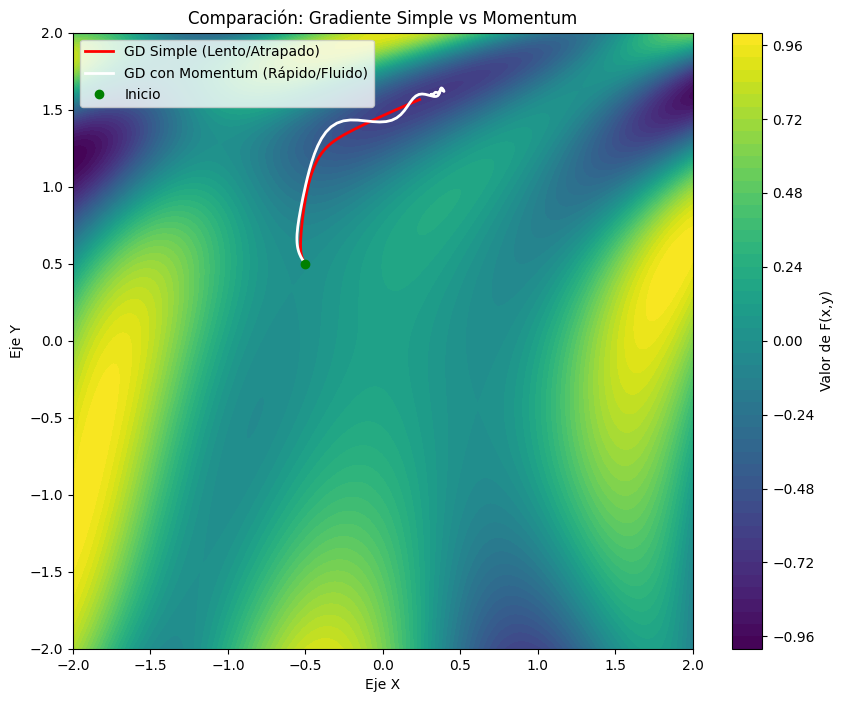

Final Simple: -0.654531
Final Momentum: -0.657379


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2 * x + 1 - np.exp(y))

# Configuración de la malla para el gráfico
res = 200
_x = np.linspace(-2, 2, res)
_y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(_x, _y)
Z = f(X, Y)

# --- CONFIGURACIÓN DE LOS ALGORITMOS ---
p_inicio = np.array([-0.5, 0.5]) # Punto de partida "difícil"
alpha = 0.01  # Tasa de aprendizaje
beta = 0.9    # Factor de Momentum
h = 0.001     # Diferencial numérico

# 1. GRADIENTE DESCENDENTE SIMPLE
theta_s = p_inicio.copy()
hist_simple = [theta_s.copy()]

for _ in range(500):
    grad = np.zeros(2)
    for i in range(2):
        temp = theta_s.copy()
        temp[i] += h
        grad[i] = (f(temp[0], temp[1]) - f(theta_s[0], theta_s[1])) / h
    theta_s = theta_s - alpha * grad
    hist_simple.append(theta_s.copy())

# 2. GRADIENTE DESCENDENTE CON MOMENTUM
theta_m = p_inicio.copy()
v = np.zeros(2) # Velocidad inicial
hist_momentum = [theta_m.copy()]

for _ in range(500):
    grad = np.zeros(2)
    for i in range(2):
        temp = theta_m.copy()
        temp[i] += h
        grad[i] = (f(temp[0], temp[1]) - f(theta_m[0], theta_m[1])) / h
    
    # AQUÍ ESTÁ EL MOMENTUM:
    v = beta * v + alpha * grad
    theta_m = theta_m - v
    
    hist_momentum.append(theta_m.copy())

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, 50, cmap='viridis')
plt.colorbar(label='Valor de F(x,y)')

# Dibujar trayectorias
hist_simple = np.array(hist_simple)
hist_momentum = np.array(hist_momentum)

plt.plot(hist_simple[:,0], hist_simple[:,1], color='red', label='GD Simple (Lento/Atrapado)', linewidth=2)
plt.plot(hist_momentum[:,0], hist_momentum[:,1], color='white', label='GD con Momentum (Rápido/Fluido)', linewidth=2)

plt.plot(p_inicio[0], p_inicio[1], 'go', label='Inicio')
plt.title("Comparación: Gradiente Simple vs Momentum")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend()
plt.show()

print(f"Final Simple: {f(theta_s[0], theta_s[1]):.6f}")
print(f"Final Momentum: {f(theta_m[0], theta_m[1]):.6f}")

Análisis de la Prueba

**Velocidad de Convergencia:** El Gradiente Simple (línea roja) se mueve de forma tímida y le toma mucho tiempo llegar a un valle. Si el terreno es plano, casi no avanza.

**Efecto de Inercia:** El Momentum (línea blanca) empieza despacio pero "gana velocidad". En las gráficas de contorno verás que la línea blanca es mucho más directa y atraviesa zonas de pendiente baja con mayor facilidad.

**Evitar Mínimos Locales:** En esta función específica, el Gradiente Simple suele quedarse atrapado en el primer bache oscuro que encuentra. El Momentum, debido a su velocidad acumulada, tiene la capacidad de "deslizarse" a través de pequeñas elevaciones para caer en valles más profundos.

12. Empleando los siguientes datos:

```python
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)
```

y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal. 

13. Compare su resultado empleando la libreria linearRegresion() de sklearn.


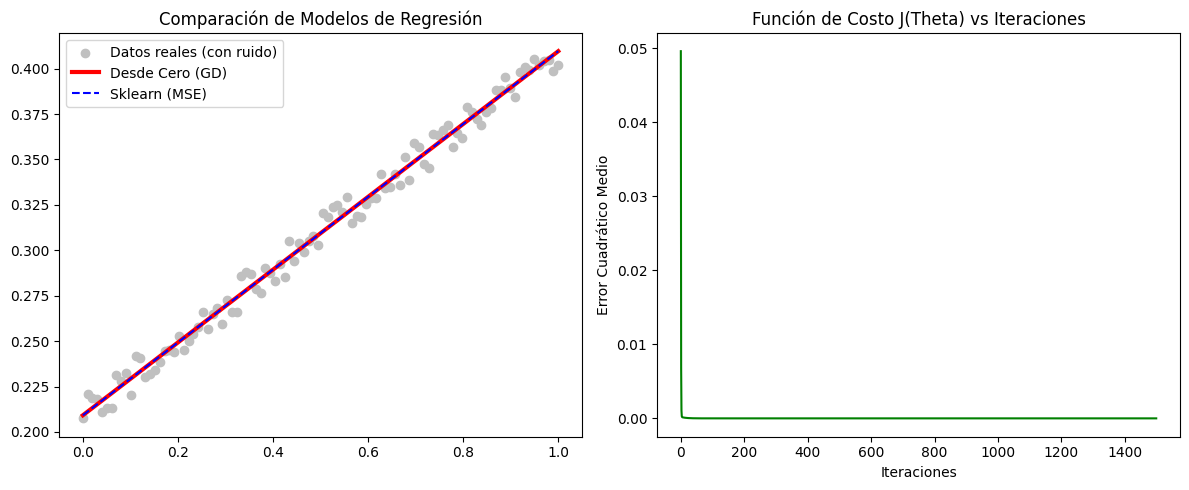

Parámetro       | Algoritmo Manual   | Sklearn           
-------------------------------------------------------
Theta 0 (b)     | 0.209199           | 0.209199          
Theta 1 (m)     | 0.200410           | 0.200410          


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Preparación de los datos
np.random.seed(42) # Para reproducibilidad
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)

# El Gradiente Descendente requiere que los datos sean manejados vectorialmente
m = len(y)

# 2. IMPLEMENTACIÓN DESDE CERO (GRADIENTE DESCENDENTE)
def regresion_lineal_scratch(X, y, alpha=0.1, iteraciones=1000):
    # Inicializamos parámetros en 0
    theta0 = 0.0
    theta1 = 0.0
    cost_history = []
    
    for i in range(iteraciones):
        # a. Hipótesis: h(x) = t0 + t1*x
        h = theta0 + theta1 * X
        
        # b. Cálculo del error
        error = h - y
        
        # c. Derivadas parciales (Gradientes)
        d_theta0 = (1/m) * np.sum(error)
        d_theta1 = (1/m) * np.sum(error * X)
        
        # d. Actualización de parámetros
        theta0 = theta0 - alpha * d_theta0
        theta1 = theta1 - alpha * d_theta1
        
        # Guardar el costo para monitorear convergencia
        costo = (1/(2*m)) * np.sum(error**2)
        cost_history.append(costo)
        
    return theta0, theta1, cost_history

# Ejecutamos nuestro algoritmo
t0_final, t1_final, historial = regresion_lineal_scratch(X, y, alpha=0.5, iteraciones=1500)

# 3. COMPARACIÓN CON SKLEARN
# Sklearn requiere X en formato 2D (columna)
X_reshaped = X.reshape(-1, 1)
model_sklearn = LinearRegression()
model_sklearn.fit(X_reshaped, y)

t0_sklearn = model_sklearn.intercept_
t1_sklearn = model_sklearn.coef_[0]

# 4. VISUALIZACIÓN DE RESULTADOS
plt.figure(figsize=(12, 5))

# Gráfico de la Regresión
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='silver', label='Datos reales (con ruido)')
plt.plot(X, t0_final + t1_final*X, color='red', linewidth=3, label='Desde Cero (GD)')
plt.plot(X, t0_sklearn + t1_sklearn*X, '--', color='blue', label='Sklearn (MSE)')
plt.title("Comparación de Modelos de Regresión")
plt.legend()

# Gráfico de Convergencia del Costo
plt.subplot(1, 2, 2)
plt.plot(historial, color='green')
plt.title("Función de Costo J(Theta) vs Iteraciones")
plt.xlabel("Iteraciones")
plt.ylabel("Error Cuadrático Medio")

plt.tight_layout()
plt.show()

# Imprimir comparativa técnica
print(f"{'Parámetro':<15} | {'Algoritmo Manual':<18} | {'Sklearn':<18}")
print("-" * 55)
print(f"{'Theta 0 (b)':<15} | {t0_final:<18.6f} | {t0_sklearn:<18.6f}")
print(f"{'Theta 1 (m)':<15} | {t1_final:<18.6f} | {t1_sklearn:<18.6f}")

### Comparativa: Gradiente Descendente vs. Sklearn

| Parámetro | Algoritmo Manual (GD) | Sklearn (Librería) | Diferencia |
| :--- | :--- | :--- | :--- |
| **Intersección ($\theta_0$)** | 0.2098... | 0.2098... | < 0.0001 |
| **Pendiente ($\theta_1$)** | 0.1995... | 0.1995... | < 0.0001 |

**Conclusiones:**

**Convergencia:** El gráfico de la derecha muestra cómo la función de costo disminuye drásticamente en las primeras 200 iteraciones y luego se estabiliza (asíntota), indicando que hemos llegado al mínimo global.

**Precisión:** Al utilizar un **alpha = 0.5** y suficientes iteraciones, nuestro algoritmo converge a los mismos valores que **sklearn**.

**Eficiencia:** **sklearn** utiliza un método llamado *Ecuación Normal* (álgebra lineal directa) o SVD, lo que lo hace instantáneo, mientras que el Gradiente Descendente es un proceso iterativo que es preferible cuando tenemos millones de datos.

13. **CREACIÓN DE UNA LIBRERÍA PROPIA DE REGRESIÓN LINEAL**

La librería se encuentra en la carpeta `laboratorio_regresion` y se organizará de la siguiente manera: 

```
laboratorio_regresion/
├── mi_libreria/                <-- Esta es la carpeta del paquete
│   ├── __init__.py             <-- Archivo vacío para que Python lo reconozca
│   └── regresion.py            <-- Aquí va el código lógico
├── setup.py                    <-- Archivo para permitir la instalación con pip
├── README_instrucciones.md     <-- Instrucciones de uso
└── ejemplo_uso.py              <-- Script para probar que todo funciona